In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"keshrivishal21","key":"4c8bb86460f4dd386e694fd83bc26447"}'}

In [2]:
!mkdir -p ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json

In [3]:
!kaggle competitions download -c state-farm-distracted-driver-detection

 99% 3.98G/4.00G [00:48<00:00, 38.0MB/s]
100% 4.00G/4.00G [00:51<00:00, 83.9MB/s]


In [4]:
!unzip -q state-farm-distracted-driver-detection.zip -d data

In [5]:
import os

print(os.listdir("/content/data/imgs/train"))

['c0', 'c3', 'c9', 'c1', 'c2', 'c6', 'c8', 'c7', 'c4', 'c5']


In [6]:
import shutil
import random
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.layers import Dense
import matplotlib.pyplot as plt

In [7]:
# paths
SOURCE_TRAIN_DIR = "/content/data/imgs/train"
PROCESSED_DIR = "/content/data/processed"

CLASS_NAMES = ["c0","c1","c2","c3","c4","c5","c6","c7","c8","c9"]

TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2

RANDOM_SEED = 42

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

In [8]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [9]:
for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        create_dir(os.path.join(PROCESSED_DIR, split, cls))

In [10]:
# data split
random.seed(RANDOM_SEED)

for cls in CLASS_NAMES:
    cls_path = os.path.join(SOURCE_TRAIN_DIR, cls)
    images = [img for img in os.listdir(cls_path) if img.endswith(".jpg")]

    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end   = int(total * (TRAIN_RATIO + VAL_RATIO))

    train_imgs = images[:train_end]
    val_imgs   = images[train_end:val_end]
    test_imgs  = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "test", cls, img)
        )

    print(f"{cls}: {len(train_imgs)} train | {len(val_imgs)} val | {len(test_imgs)} test")

c0: 1493 train | 498 val | 498 test
c1: 1360 train | 453 val | 454 test
c2: 1390 train | 463 val | 464 test
c3: 1407 train | 469 val | 470 test
c4: 1395 train | 465 val | 466 test
c5: 1387 train | 462 val | 463 test
c6: 1395 train | 465 val | 465 test
c7: 1201 train | 400 val | 401 test
c8: 1146 train | 382 val | 383 test
c9: 1277 train | 426 val | 426 test


In [11]:
def count_images(split):
    total = 0
    for cls in CLASS_NAMES:
        total += len(os.listdir(os.path.join(PROCESSED_DIR, split, cls)))
    return total

print("Train images:", count_images("train"))
print("Val images:", count_images("val"))
print("Test images:", count_images("test"))

Train images: 13451
Val images: 4483
Test images: 4490


In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/val",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

Found 13451 files belonging to 10 classes.
Found 4483 files belonging to 10 classes.
Found 4490 files belonging to 10 classes.


In [13]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (16, 224, 224, 3)
Labels shape: (16, 10)


In [14]:
def depth_separable_cnn(input_shape=(224,224,3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # Normalization
    x = layers.Rescaling(1./255)(inputs)

    # Block 1
    x = layers.SeparableConv2D(6, (3,3),padding="same",activation="relu")(x)
    x = layers.SeparableConv2D(6, (3,3),padding="same",activation="relu")(x)
    x = layers.AveragePooling2D((2,2))(x)

    # Flatten
    x = layers.Flatten()(x)

    # Dense
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs,name="Proposed_Separable_CNN")
    return model

In [15]:
model = depth_separable_cnn()
model.summary()

Model: "Proposed_Separable_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 224, 224, 6)    │            51 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 224, 224, 6)    │            96 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 6)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 75264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       752,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 752,797 (2.87 MB)

 Trainable params: 752,797 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 47s 46ms/step - accuracy: 0.3349 - loss: 1.9182 - val_accuracy: 0.8488 - val_loss: 0.5472
Epoch 2/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - accuracy: 0.8979 - loss: 0.3885 - val_accuracy: 0.9458 - val_loss: 0.2167
Epoch 3/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9613 - loss: 0.1569 - val_accuracy: 0.9594 - val_loss: 0.1547
Epoch 4/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.9731 - loss: 0.1041 - val_accuracy: 0.9625 - val_loss: 0.1253
Epoch 5/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.9835 - loss: 0.0623 - val_accuracy: 0.9556 - val_loss: 0.1462
Epoch 6/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9872 - loss: 0.0489 - val_accuracy: 0.9672 - val_loss: 0.1102
Epoch 7/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9911 - loss: 0.0362 - val_accuracy: 0.9692 - val_loss: 0.1093
Epoch 8/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9883 - loss: 0

In [17]:
model.save("/content/data/models/Proposed_Separable_CNN.keras")

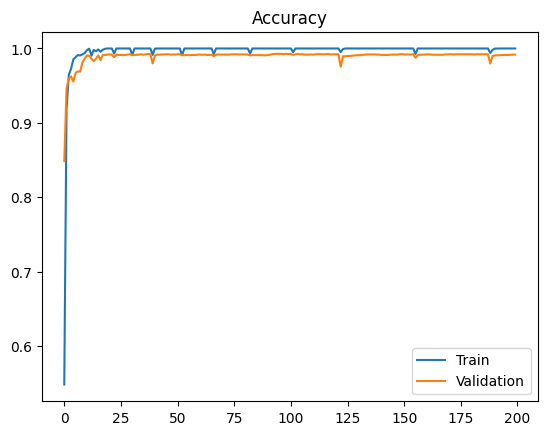

In [18]:
# Accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

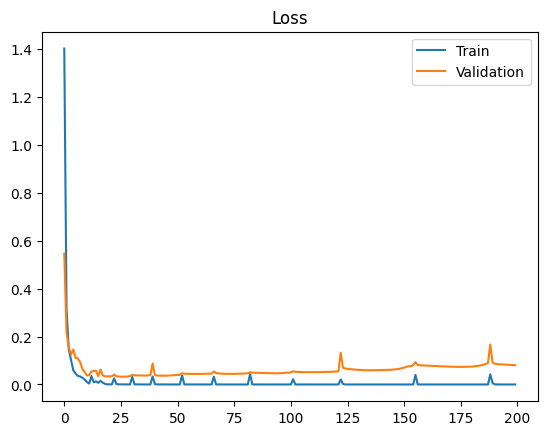

In [19]:
# Loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [20]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9973 - loss: 0.0305
Test Accuracy: 0.994209349155426


In [21]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (ms):", time_per_image * 1000)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
Time per image (ms): 39.44401443004608
